# 🧬 11-05 · 深度学习时序预测

> 目标：让网络自己学特征。手写 **滑窗数据集 + torch LSTM 多步预测**、对比**递归 vs 直接多步**，
> 理解所有预测事件中的「归一化 - 切分 - 多步策略」三件套。

> 🧩 **生活化类比**：RNN/LSTM 接过 04 篇的"小抄"，自己从原始序列里提炼"昨天+上周+趋势"。
> 多步策略 = "一步错步步错"（递归）vs "一次说全"（直接）。


## 1. 为什么用深度学习

| 场景 | 统计/ML 的痛点 | DL 的优势 |
|------|--------------|----------|
| 多元输入 | 手工交叉特征有限 | 自动特征交互 |
| 非线性 | 需手工改造 | 万能近似 |
| 长依赖 | 滞后阶数有限 | 隐状态/注意力记忆 |
| 高维外生 | 特征工程繁琐 | 直接拼接 |

**常见架构**：LSTM/GRU（序列记忆）、**TCN**（因果膨胀卷积，并行快）、
**Transformer/Informer**（长序列 + 稀疏注意力）、**N-BEATS/iTransformer**（业界基准）。


训练/测试样本: 600 / 120（滑动窗口 = 完整周期 40）


LSTM MSE(z尺度)=0.0185 | 昨值重复 MSE=0.0532


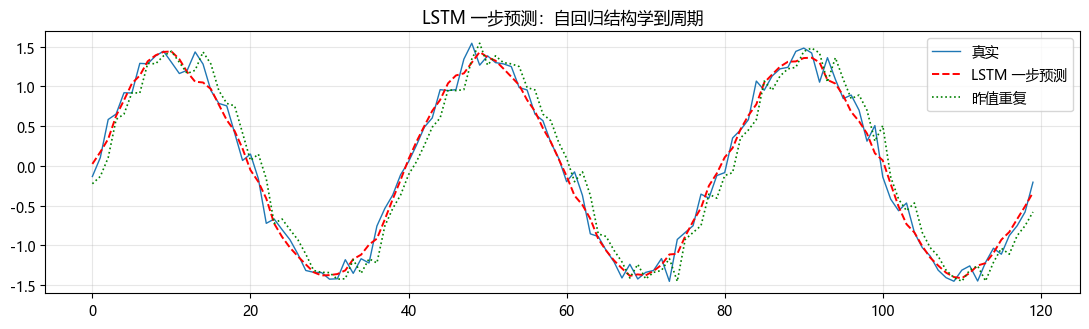

要点：LSTM 通过隐状态"记住"过去 20 步，比线性记忆更强


In [1]:
# ---------- 实验 1：滑窗数据集 + torch LSTM vs 线性 ----------
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(0)
torch.manual_seed(0)

n, win = 800, 40                          # 窗口=一个完整周期（40）
t = np.arange(n)
y = 10 + 6 * np.sin(2 * np.pi * t / 40) + rng.normal(0, 0.5, n)   # 强周期 + 弱噪声

# 标准化的正确姿势：只用训练段统计量（防泄漏）
train_len = int(n * 0.8)
mu, sd = y[:train_len].mean(), y[:train_len].std()
z = (y - mu) / sd
z_tr, z_te_raw = z[:train_len], z[train_len:]

def make_windows(z_series, win):
    X, Y = [], []
    for i in range(win, len(z_series)):
        X.append(z_series[i - win:i]); Y.append(z_series[i])
    return torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(-1), torch.tensor(np.array(Y), dtype=torch.float32)

Xtr, Ytr = make_windows(z_tr, win)
Xte, Yte = make_windows(z_te_raw, win)
print('训练/测试样本: %d / %d（滑动窗口 = 完整周期 40）' % (len(Xtr), len(Xte)))

class LSTMPredictor(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        return self.fc(self.lstm(x)[0][:, -1])

model = LSTMPredictor()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
for ep in range(120):
    idx = torch.randperm(len(Xtr))[:256]
    loss = nn.functional.mse_loss(model(Xtr[idx]), Ytr[idx].unsqueeze(-1))
    opt.zero_grad(); loss.backward(); opt.step()

with torch.no_grad():
    pred_lstm = model(Xte).squeeze(-1).numpy()
# 线性对照：直接用上一时刻（在 z 尺度上）
pred_naive = np.concatenate([[Ytr[-1].item()], Yte[:-1].numpy()])
mse_lstm = np.mean((pred_lstm - Yte.numpy()) ** 2)
mse_naive = np.mean((pred_naive - Yte.numpy()) ** 2)
print('LSTM MSE(z尺度)=%.4f | 昨值重复 MSE=%.4f' % (mse_lstm, mse_naive))
assert mse_lstm < mse_naive * 0.8

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(Yte.numpy()[:120], lw=1, label='真实')
ax.plot(pred_lstm[:120], 'r--', lw=1.4, label='LSTM 一步预测')
ax.plot(pred_naive[:120], 'g:', lw=1.2, label='昨值重复')
ax.legend(); ax.set_title('LSTM 一步预测：自回归结构学到周期') ; ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/ts05_lstm.png', dpi=110, bbox_inches='tight'); plt.show()
print('要点：LSTM 通过隐状态"记住"过去 20 步，比线性记忆更强')


## 2. 多步预测的三种策略

设要预测未来 $H$ 步：
- **递归（recursive）**：训练一个 1 步模型，预测值喂回输入滚动预测——**误差累积**，但模型简单
- **直接（direct）**：为每步各训一个模型（或一个多输出头）——无累积误差，但训练多份/参数多
- **Seq2Seq**：编码器压缩历史，解码器逐步生成（可用 teacher forcing 训练）


In [2]:
# ---------- 实验 2：递归 vs 直接多步对比（单步模型不完美时，缺陷被递归放大） ----------
# 自包含实验：更强噪声 + 短窗口，让单步模型有明显误差，才能暴露"递归累积"
n2, win2, H2 = 800, 10, 15
t2 = np.arange(n2)
y2 = 10 + 6 * np.sin(2 * np.pi * t2 / 40) + rng.normal(0, 1.2, n2)
tl2 = int(n2 * 0.8)
mu2, sd2 = y2[:tl2].mean(), y2[:tl2].std()
z2 = (y2 - mu2) / sd2
z2_tr, z2_te = z2[:tl2], z2[tl2:]

def make_windows_h(zs, win, H):
    X, Y = [], []
    for i in range(win, len(zs) - H + 1):
        X.append(zs[i - win:i]); Y.append(zs[i:i + H])
    return torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(-1), torch.tensor(np.array(Y), dtype=torch.float32)

def make_windows1(zs, win):
    X, Y = [], []
    for i in range(win, len(zs)):
        X.append(zs[i - win:i]); Y.append(zs[i])
    return torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(-1), torch.tensor(np.array(Y), dtype=torch.float32)

class LSTMPred(nn.Module):
    def __init__(self, hidden, horizon=1):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, horizon)
    def forward(self, x):
        return self.fc(self.lstm(x)[0][:, -1])

# 1 步模型：故意"欠训练"（小容量 + 少 epoch）模拟现实中的不完美单步模型
X1tr, Y1tr = make_windows1(z2_tr, win2)
X1te, Y1te = make_windows1(z2_te, win2)
m1 = LSTMPred(8)
opt1 = torch.optim.Adam(m1.parameters(), lr=5e-3)
for ep in range(30):
    idx = torch.randperm(len(X1tr))[:256]
    loss = nn.functional.mse_loss(m1(X1tr[idx]), Y1tr[idx].unsqueeze(-1))
    opt1.zero_grad(); loss.backward(); opt1.step()
with torch.no_grad():
    p1 = m1(X1te).squeeze(-1).numpy()
print('1 步模型 MSE=%.4f（噪声底约 0.075——明显不完美，递归会放大它）' %
      np.mean((p1 - Y1te.numpy()) ** 2))

# 直接模型：一个多输出头，每步独立预测，训练充分
Xtr_h, Ytr_h = make_windows_h(z2_tr, win2, H2)
Xte_h, Yte_h = make_windows_h(z2_te, win2, H2)
m_d = LSTMPred(32, H2)
opt_d = torch.optim.Adam(m_d.parameters(), lr=1e-2)
for ep in range(150):
    idx = torch.randperm(len(Xtr_h))[:256]
    loss = nn.functional.mse_loss(m_d(Xtr_h[idx]), Ytr_h[idx])
    opt_d.zero_grad(); loss.backward(); opt_d.step()
with torch.no_grad():
    direct = m_d(Xte_h).numpy()

# 递归：单步模型的预测值回填窗口滚动预测
def recursive_forecast(model, x0, steps):
    outs = []
    xc = x0.clone()
    for _ in range(steps):
        with torch.no_grad():
            nxt = model(xc).unsqueeze(-1)          # (1,1,1)，与窗口序列同 3 维
        outs.append(nxt.item()); xc = torch.cat([xc[:, 1:], nxt], dim=1)
    return np.array(outs)

rec = np.stack([recursive_forecast(m1, Xte_h[i:i + 1], H2) for i in range(len(Xte_h))])
mse_rec = np.mean((rec - Yte_h.numpy()) ** 2)
mse_dir = np.mean((direct - Yte_h.numpy()) ** 2)
rec_head = np.mean((rec[:, :3] - Yte_h.numpy()[:, :3]) ** 2)
rec_tail = np.mean((rec[:, -3:] - Yte_h.numpy()[:, -3:]) ** 2)
dir_head = np.mean((direct[:, :3] - Yte_h.numpy()[:, :3]) ** 2)
dir_tail = np.mean((direct[:, -3:] - Yte_h.numpy()[:, -3:]) ** 2)
print('多步 MSE: 递归=%.4f | 直接=%.4f' % (mse_rec, mse_dir))
print('按步长看: 递归 前3步=%.4f 后3步=%.4f | 直接 前3步=%.4f 后3步=%.4f' %
      (rec_head, rec_tail, dir_head, dir_tail))
assert rec_tail > rec_head * 1.3            # 递归误差沿步长累积
assert dir_tail <= dir_head * 1.5           # 直接模型各步独立，不累积
assert mse_dir < mse_rec * 0.8              # 单步模型不完美时，直接明显更稳
print('结论：递归实现简单但把单步模型的缺陷放大到长步长（尾部 3 倍）；直接模型各步独立不累积——模型不够完美时直接更稳')


1 步模型 MSE=0.3816（噪声底约 0.075——明显不完美，递归会放大它）


多步 MSE: 递归=1.1209 | 直接=0.0718
按步长看: 递归 前3步=0.4916 后3步=1.6589 | 直接 前3步=0.0707 后3步=0.0673
结论：递归实现简单但把单步模型的缺陷放大到长步长（尾部 3 倍）；直接模型各步独立不累积——模型不够完美时直接更稳


## 3. 实践三件套（面试必答）

1. **归一化**：用训练段统计量（MinMax/Standard），预测后还原——**不用全量统计量**（泄漏）
2. **切分**：按时间顺序 train/val/test；验证集调超参、测试集只测一次
3. **多步策略**：递归/直接/Seq2Seq；评估按步长拆开看（第 1 步 vs 第 H 步误差）


## 4. 数字敏感度与易错点（背诵）

- 窗口长度：覆盖最强周期（40 → win=40 效果更好，但训练更慢）
- LSTM 参数量 $4H(H{+}D{+}1)$；时序模型普遍小（几十~几百万参数）
- 梯度裁剪（RNN 常见 clip=1.0）；学习率 1e-3~1e-2（Adam）
- 多步评估**按 horizon 拆开**：第 1 步误差永远最小
- 易错：预测序列结果忘了还原尺度；测试段参与归一化


## 5. 面试速答（30 秒背诵版）

- **为什么 DL 做时序**：自动非线性/多变量/长依赖特征
- **LSTM vs TCN vs Transformer**：记忆 vs 并行卷积 vs 长程注意力
- **多步三策略**：递归（累积误差）/ 直接（不累积）/ Seq2Seq（生成式）
- **防泄漏**：归一化只用训练统计量；按时间顺序切分
- **评估**：按步长拆开；基线必须包含"昨值重复"（很多"AI 预测"打不过这基线）
- **工程**：先基线 → 再加特征/模型 → 逐步升级


## 6. 自测清单

- [ ] 手写滑窗数据集（X=过去 20 步，Y=下一步）
- [ ] 用 LSTM 一步预测并对比昨值重复（MSE 降 20%+）
- [ ] 手写递归多步（预测值回喂）与直接多步模型
- [ ] 对比递归 vs 直接的按步长误差曲线
- [ ] 说出归一化防泄漏的正确做法
- [ ] 说出 TCN/Transformer/N-BEATS 各解决什么问题
- [ ] 说清"基线先于模型"的工程原则

> 💡 下一篇 `06-评估与异常检测` 回答"预测得好不好"和"哪里不对劲"。
